# ADAM vs ADAMCB Log File Analysis

This notebook analyzes and visualizes the training log data from `adam_vs_adamcb_comparision.log`.

We will extract and plot key metrics for both ADAM and ADAMCB optimizers, including:
- Train Loss
- Test Loss
- Test Accuracy
- Unique Items Seen
- Batch Gradients (Min, Mean, Max)

Comparative plots and brief analysis will be provided for each metric.

## 1. Import Required Libraries

We will use pandas for data handling, matplotlib and seaborn for visualization, and re for parsing the log file.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set(style="whitegrid")

## 2. Load and Preview the .log File

Read the log file and display the first few lines to inspect its structure.

In [2]:
# Read the log file
log_path = "adam_vs_adamcb_comparision.log"
with open(log_path, 'r') as f:
    lines = f.readlines()

# Display the first 20 lines
for line in lines[:20]:
    print(line.strip())

nohup: ignoring input
Using device: cuda

Starting CIFAR-10 Experiment: 4210 total batches (54000 Train, 6000 Test)...

[============================== STEP 1/4210 (Epoch 1) ==============================]
[PERFORMANCE COMPARISON]
ADAM   | Train Loss: 2.3215 | Test Loss: 2.2238 | Test Acc: 18.28%
ADAMCB | Train Loss: 2.3226 | Test Loss: 2.2065 | Test Acc: 20.93%
--------------------------------------------------------------------------------
[DIAGNOSTICS & BEHAVIOR]
ADAM   -> Unique Items Seen: 128 / 54000
ADAMCB -> Unique Items Seen: 128 / 54000
ADAMCB -> Dataset Weights  : 0 easy items (floor 0.1) | 53946 hard items (ceil 1.0)
ADAM   -> Batch Gradients  : Min=4.5523 | Mean=9.4451 | Max=18.9959
ADAMCB -> Batch Gradients  : Min=4.5182 | Mean=9.7924 | Max=16.5097

[============================== STEP 2/4210 (Epoch 1) ==============================]
[PERFORMANCE COMPARISON]
ADAM   | Train Loss: 2.1712 | Test Loss: 2.1885 | Test Acc: 21.35%


## 3. Parse Relevant Data from the Log File

Extract step, epoch, and all relevant metrics for ADAM and ADAMCB using regular expressions.

In [3]:
# Regular expressions for parsing
step_re = re.compile(r'STEP (\d+)/(\d+) \(Epoch (\d+)\)')
perf_re = re.compile(r'(ADAMCB|ADAM)\s+\| Train Loss: ([\d.]+) \| Test Loss: ([\d.]+) \| Test Acc: ([\d.]+)%')
unique_re = re.compile(r'(ADAMCB|ADAM) -> Unique Items Seen: (\d+) / (\d+)')
grad_re = re.compile(r'(ADAMCB|ADAM) -> Batch Gradients  : Min=([\d.]+) \| Mean=([\d.]+) \| Max=([\d.]+)')

# Data storage
records = []
current_step = None
current_epoch = None

for i, line in enumerate(lines):
    step_match = step_re.search(line)
    if step_match:
        current_step = int(step_match.group(1))
        total_steps = int(step_match.group(2))
        current_epoch = int(step_match.group(3))
    perf_match = perf_re.search(line)
    if perf_match and current_step is not None:
        opt = perf_match.group(1)
        train_loss = float(perf_match.group(2))
        test_loss = float(perf_match.group(3))
        test_acc = float(perf_match.group(4))
        # Look ahead for unique items and gradients
        unique_seen = None
        grad_min = grad_mean = grad_max = None
        for j in range(i+1, min(i+10, len(lines))):
            unique_match = unique_re.search(lines[j])
            grad_match = grad_re.search(lines[j])
            if unique_match and unique_match.group(1) == opt:
                unique_seen = int(unique_match.group(2))
            if grad_match and grad_match.group(1) == opt:
                grad_min = float(grad_match.group(2))
                grad_mean = float(grad_match.group(3))
                grad_max = float(grad_match.group(4))
        records.append({
            'step': current_step,
            'epoch': current_epoch,
            'optimizer': opt,
            'train_loss': train_loss,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'unique_seen': unique_seen,
            'grad_min': grad_min,
            'grad_mean': grad_mean,
            'grad_max': grad_max
        })

# Create DataFrame
df = pd.DataFrame(records)
df.head()

,step,epoch,optimizer,train_loss,test_loss,test_acc,unique_seen,grad_min,grad_mean,grad_max
0,1,1,ADAM,2.3215,2.2238,18.28,NaN,NaN,NaN,NaN
1,1,1,ADAMCB,2.3226,2.2065,20.93,128.0,4.5182,9.7924,16.5097
2,2,1,ADAM,2.1712,2.1885,21.35,NaN,NaN,NaN,NaN
3,2,1,ADAMCB,2.2237,2.1910,22.45,256.0,4.6428,11.5955,26.2988
4,3,1,ADAM,2.2000,2.1061,25.12,NaN,NaN,NaN,NaN


## 4. Visualize Log Data: Line Plots

Plot Train Loss, Test Loss, and Test Accuracy over steps for both optimizers.

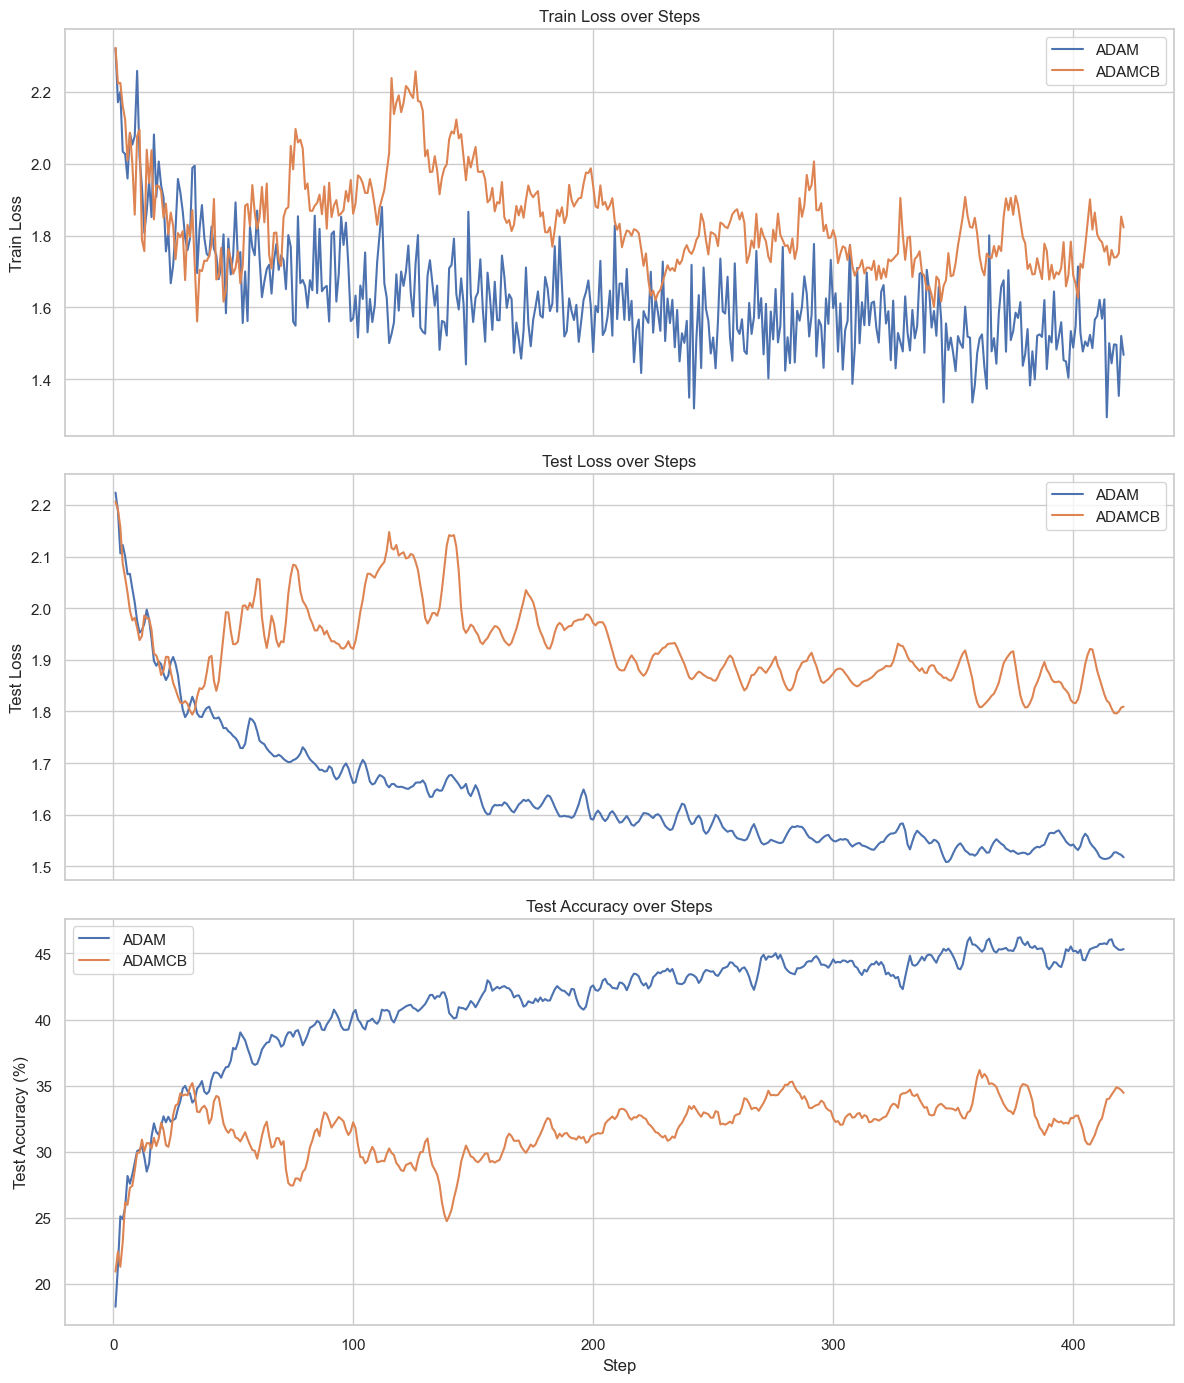

In [4]:
# Plot Train Loss, Test Loss, and Test Accuracy
fig, axs = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

for opt in ['ADAM', 'ADAMCB']:
    sub = df[df['optimizer'] == opt]
    axs[0].plot(sub['step'], sub['train_loss'], label=opt)
    axs[1].plot(sub['step'], sub['test_loss'], label=opt)
    axs[2].plot(sub['step'], sub['test_acc'], label=opt)

axs[0].set_ylabel('Train Loss')
axs[1].set_ylabel('Test Loss')
axs[2].set_ylabel('Test Accuracy (%)')
axs[2].set_xlabel('Step')
axs[0].set_title('Train Loss over Steps')
axs[1].set_title('Test Loss over Steps')
axs[2].set_title('Test Accuracy over Steps')
for ax in axs:
    ax.legend()
plt.tight_layout()
plt.show()

## 5. Visualize Log Data: Histograms

Plot histograms to analyze the distribution of Test Accuracy and Unique Items Seen for both optimizers.

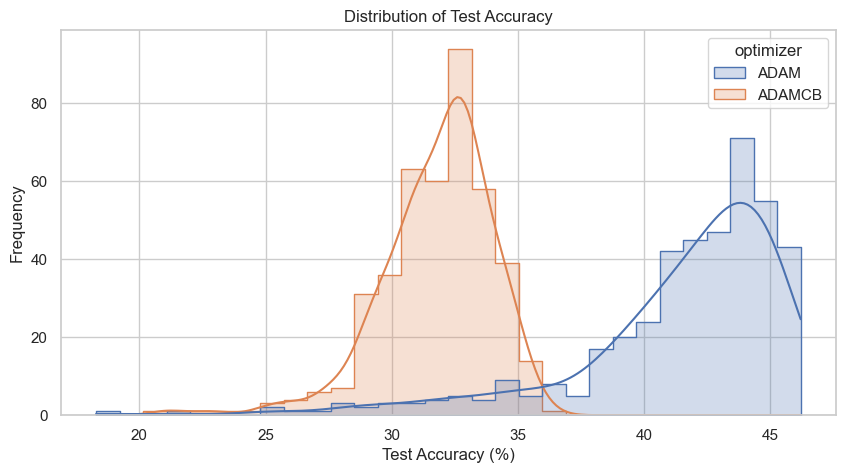

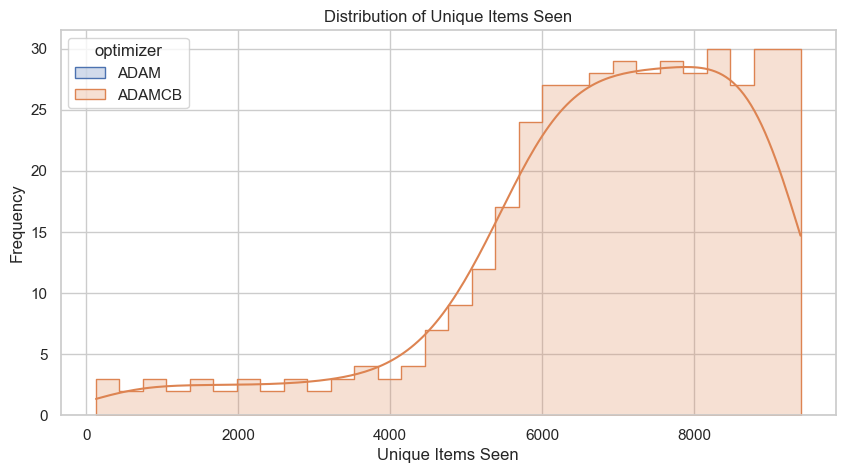

In [5]:
# Histogram of Test Accuracy
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='test_acc', hue='optimizer', bins=30, kde=True, element='step')
plt.title('Distribution of Test Accuracy')
plt.xlabel('Test Accuracy (%)')
plt.ylabel('Frequency')
plt.show()

# Histogram of Unique Items Seen
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='unique_seen', hue='optimizer', bins=30, kde=True, element='step')
plt.title('Distribution of Unique Items Seen')
plt.xlabel('Unique Items Seen')
plt.ylabel('Frequency')
plt.show()

## 6. Visualize Log Data: Error/Warning Frequency

Plot Batch Gradients (Min, Mean, Max) over steps for both optimizers to analyze gradient behavior.

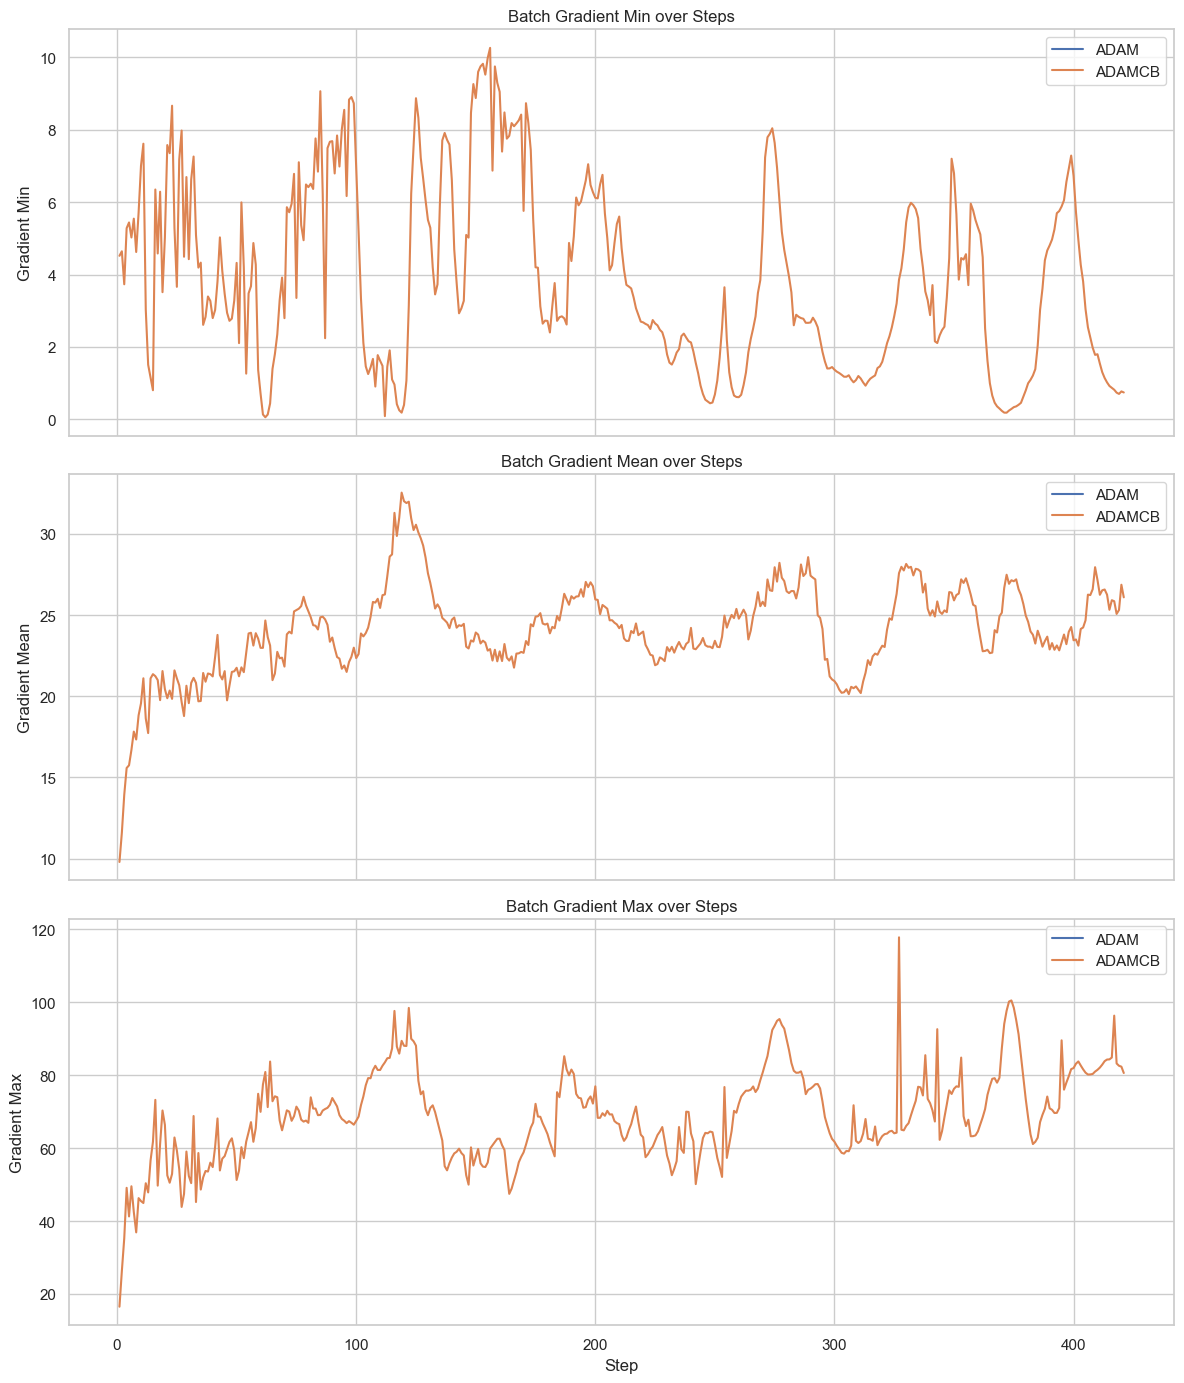

In [6]:
# Plot Batch Gradients (Min, Mean, Max)
fig, axs = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

for opt in ['ADAM', 'ADAMCB']:
    sub = df[df['optimizer'] == opt]
    axs[0].plot(sub['step'], sub['grad_min'], label=opt)
    axs[1].plot(sub['step'], sub['grad_mean'], label=opt)
    axs[2].plot(sub['step'], sub['grad_max'], label=opt)

axs[0].set_ylabel('Gradient Min')
axs[1].set_ylabel('Gradient Mean')
axs[2].set_ylabel('Gradient Max')
axs[2].set_xlabel('Step')
axs[0].set_title('Batch Gradient Min over Steps')
axs[1].set_title('Batch Gradient Mean over Steps')
axs[2].set_title('Batch Gradient Max over Steps')
for ax in axs:
    ax.legend()
plt.tight_layout()
plt.show()

## 7. Weights and Probabilities Analysis

Analyze and visualize the dataset weights (easy/hard items) and, if available, the probabilities or distributions implied by these weights for ADAMCB.

In [7]:
# Parse ADAMCB weights (easy/hard items) from log
weights_re = re.compile(r'ADAMCB -> Dataset Weights  : (\d+) easy items \(floor [\d.]+\) \| (\d+) hard items \(ceil [\d.]+\)')

weights_records = []
current_step = None
for i, line in enumerate(lines):
    step_match = step_re.search(line)
    if step_match:
        current_step = int(step_match.group(1))
    weights_match = weights_re.search(line)
    if weights_match and current_step is not None:
        easy = int(weights_match.group(1))
        hard = int(weights_match.group(2))
        weights_records.append({'step': current_step, 'easy': easy, 'hard': hard})

weights_df = pd.DataFrame(weights_records)
weights_df.head()

,step,easy,hard
0,1,0,53946
1,2,0,53881
2,3,0,53818
3,4,0,53818
4,5,0,53782


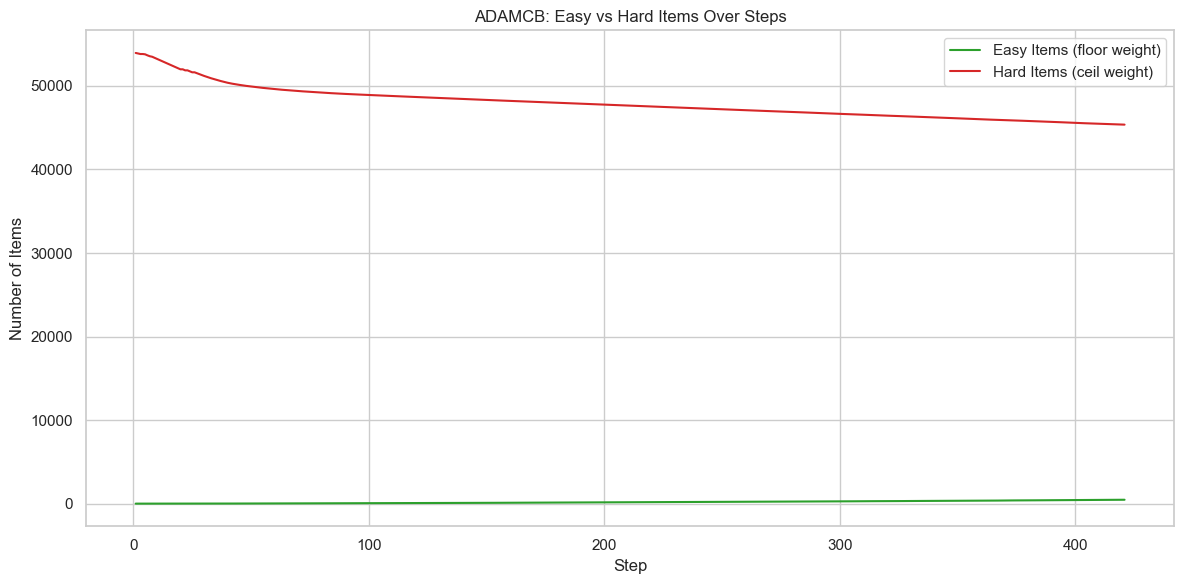

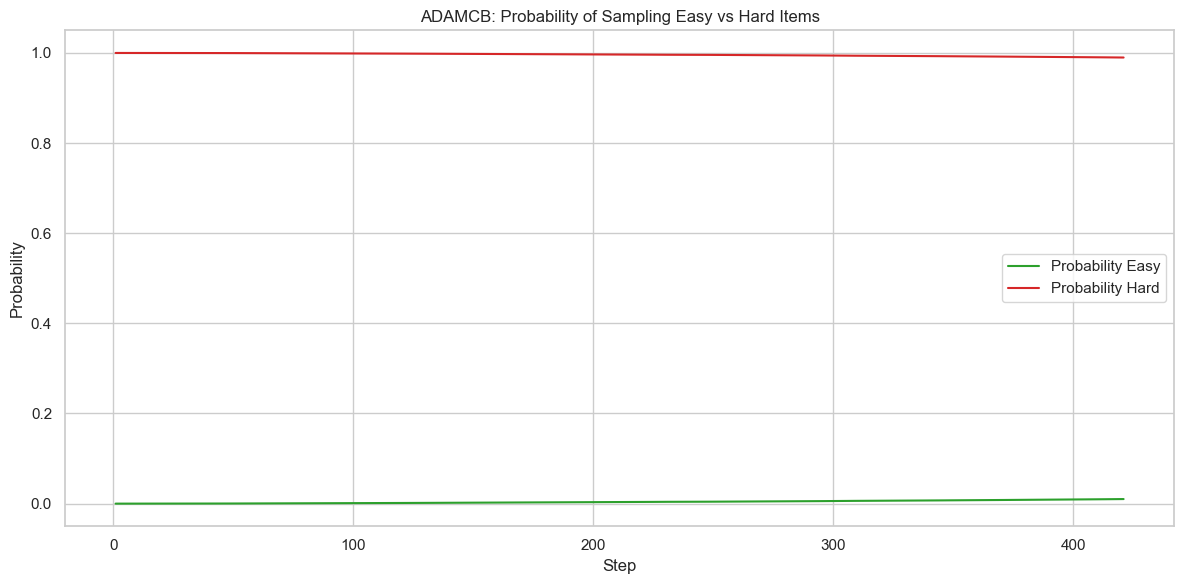

In [8]:
# Plot easy vs hard items over steps for ADAMCB
plt.figure(figsize=(12, 6))
plt.plot(weights_df['step'], weights_df['easy'], label='Easy Items (floor weight)', color='tab:green')
plt.plot(weights_df['step'], weights_df['hard'], label='Hard Items (ceil weight)', color='tab:red')
plt.xlabel('Step')
plt.ylabel('Number of Items')
plt.title('ADAMCB: Easy vs Hard Items Over Steps')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate and plot the probability of sampling an easy vs hard item (if total is known)
if not weights_df.empty:
    weights_df['total'] = weights_df['easy'] + weights_df['hard']
    weights_df['prob_easy'] = weights_df['easy'] / weights_df['total']
    weights_df['prob_hard'] = weights_df['hard'] / weights_df['total']
    plt.figure(figsize=(12, 6))
    plt.plot(weights_df['step'], weights_df['prob_easy'], label='Probability Easy', color='tab:green')
    plt.plot(weights_df['step'], weights_df['prob_hard'], label='Probability Hard', color='tab:red')
    plt.xlabel('Step')
    plt.ylabel('Probability')
    plt.title('ADAMCB: Probability of Sampling Easy vs Hard Items')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 8. Batch Analysis: All Log Files

This section will process all `adam_vs_adamcb_comparision.log` files in sibling experiment folders, extract weights/probabilities, and generate comparative plots.

In [9]:
import glob, os

# Find all log files in sibling experiment folders
glob_pattern = os.path.join('..', '*', 'adam_vs_adamcb_comparision.log')
log_files = glob.glob(glob_pattern)
log_files = [os.path.abspath(f) for f in log_files]
print(f"Found {len(log_files)} log files:")
for f in log_files:
    print(f)

Found 11 log files:
/home/ganesh/NeurIPS/ADAMCB/Adam_scratch/adam_vs_adamcb_comparision.log
/home/ganesh/NeurIPS/ADAMCB/adamcb_vs_adam_small_3/adam_vs_adamcb_comparision.log
/home/ganesh/NeurIPS/ADAMCB/adamcb_vs_adam_6/adam_vs_adamcb_comparision.log
/home/ganesh/NeurIPS/ADAMCB/adamcb_vs_adam_5/adam_vs_adamcb_comparision.log
/home/ganesh/NeurIPS/ADAMCB/Adam_vs_Adamcb_3/adam_vs_adamcb_comparision.log
/home/ganesh/NeurIPS/ADAMCB/adamcb_vs_adam_4/adam_vs_adamcb_comparision.log
/home/ganesh/NeurIPS/ADAMCB/adamcb_vs_adam_7/adam_vs_adamcb_comparision.log
/home/ganesh/NeurIPS/ADAMCB/adamcb_vs_adam_small_2/adam_vs_adamcb_comparision.log
/home/ganesh/NeurIPS/ADAMCB/adamcb_vs_adam_small/adam_vs_adamcb_comparision.log
/home/ganesh/NeurIPS/ADAMCB/adamcb_vs_adam_small_4/adam_vs_adamcb_comparision.log
/home/ganesh/NeurIPS/ADAMCB/Adam_vs_Adamcb_2/adam_vs_adamcb_comparision.log


In [10]:
# Function to parse weights from a log file
def parse_weights_from_log(log_path):
    with open(log_path, 'r') as f:
        lines = f.readlines()
    weights_re = re.compile(r'ADAMCB -> Dataset Weights  : (\d+) easy items \(floor [\d.]+\) \| (\d+) hard items \(ceil [\d.]+\)')
    step_re = re.compile(r'STEP (\d+)/(\d+)')
    records = []
    current_step = None
    for line in lines:
        step_match = step_re.search(line)
        if step_match:
            current_step = int(step_match.group(1))
        weights_match = weights_re.search(line)
        if weights_match and current_step is not None:
            easy = int(weights_match.group(1))
            hard = int(weights_match.group(2))
            records.append({'step': current_step, 'easy': easy, 'hard': hard})
    df = pd.DataFrame(records)
    return df

# Parse all logs
all_weights = {}
for log_path in log_files:
    exp_name = os.path.basename(os.path.dirname(log_path))
    dfw = parse_weights_from_log(log_path)
    if not dfw.empty:
        dfw['exp'] = exp_name
        dfw['total'] = dfw['easy'] + dfw['hard']
        dfw['prob_easy'] = dfw['easy'] / dfw['total']
        dfw['prob_hard'] = dfw['hard'] / dfw['total']
        all_weights[exp_name] = dfw

# Combine for plotting
if all_weights:
    weights_all_df = pd.concat(all_weights.values(), ignore_index=True)
    print(weights_all_df.head())
else:
    print('No weights data found in logs.')

   step  easy  hard                     exp  total  prob_easy  prob_hard
0     1     0   631  adamcb_vs_adam_small_3    631        0.0        1.0
1     2     0   624  adamcb_vs_adam_small_3    624        0.0        1.0
2     3     0   616  adamcb_vs_adam_small_3    616        0.0        1.0
3     4     0   608  adamcb_vs_adam_small_3    608        0.0        1.0
4     5     0   602  adamcb_vs_adam_small_3    602        0.0        1.0


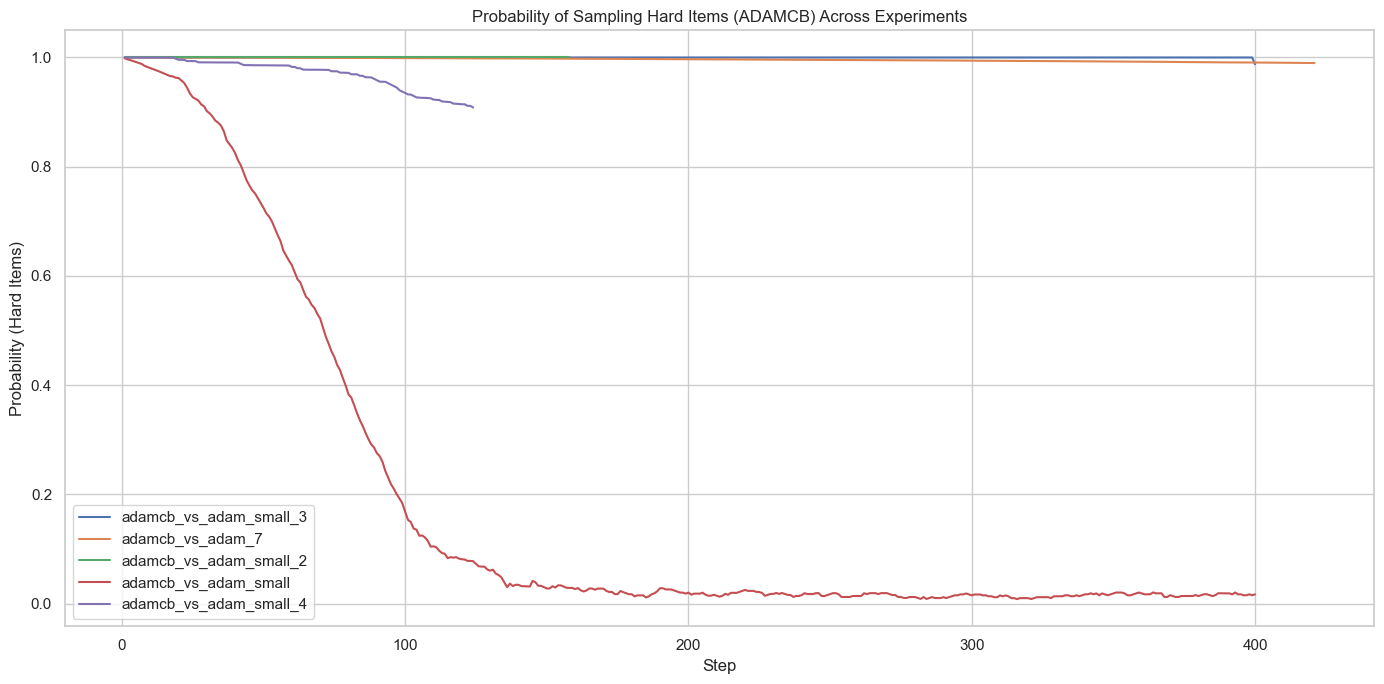

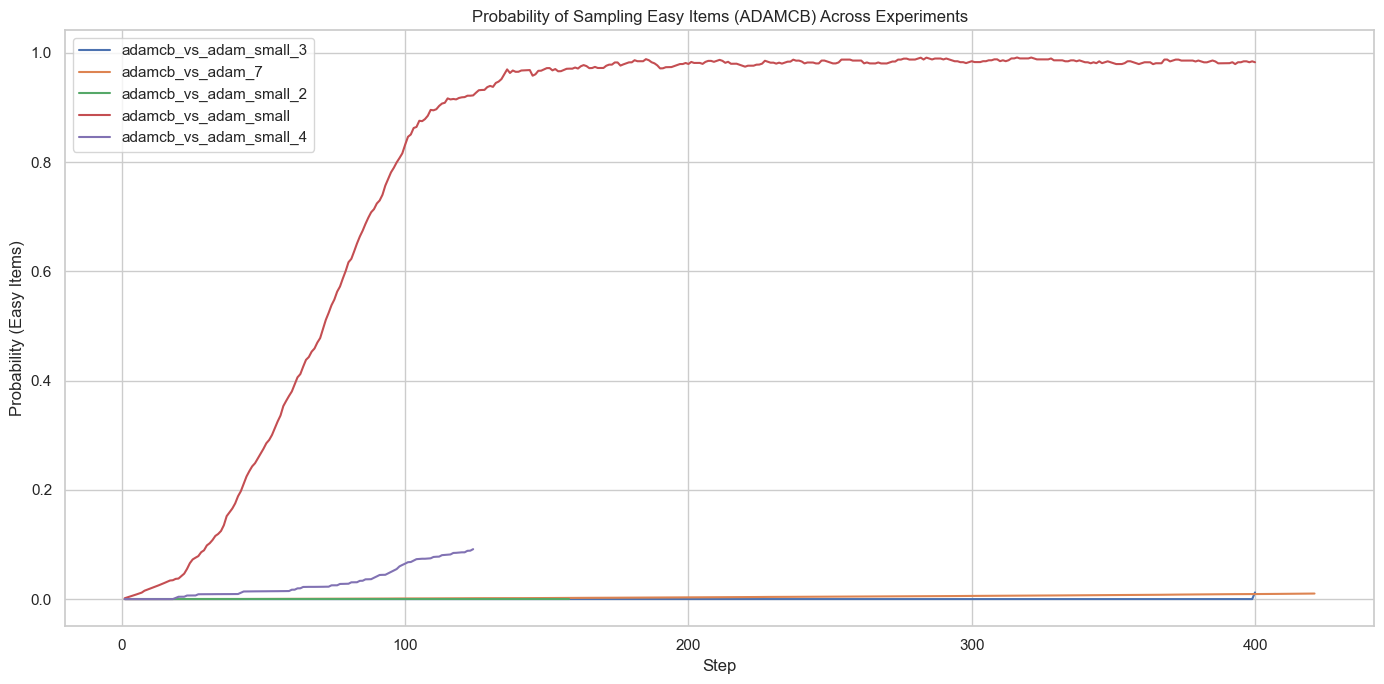

In [11]:
# Plot probability of sampling hard items for each experiment
if all_weights:
    plt.figure(figsize=(14, 7))
    for exp, dfw in all_weights.items():
        plt.plot(dfw['step'], dfw['prob_hard'], label=f'{exp}')
    plt.xlabel('Step')
    plt.ylabel('Probability (Hard Items)')
    plt.title('Probability of Sampling Hard Items (ADAMCB) Across Experiments')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 7))
    for exp, dfw in all_weights.items():
        plt.plot(dfw['step'], dfw['prob_easy'], label=f'{exp}')
    plt.xlabel('Step')
    plt.ylabel('Probability (Easy Items)')
    plt.title('Probability of Sampling Easy Items (ADAMCB) Across Experiments')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No weights data to plot.')